# 💥 Car Crashes Dataset — анализ аварийности по штатам США

Встроенный датасет seaborn **`car_crashes`**: статистика смертельных ДТП по 50 штатам + округ Колумбия (51 строка).

**Столбцы** (значения — на 1 млрд миль пробега):
- `total` — всего водителей в смертельных авариях
- `speeding` — из них превышали скорость
- `alcohol` — были пьяны
- `not_distracted` — НЕ были отвлечены
- `no_previous` — без аварий в прошлом
- `ins_premium` — средняя страховая премия ($)
- `ins_losses` — средние страховые потери ($)
- `abbrev` — код штата

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

df = sns.load_dataset('car_crashes')
print('Размер:', df.shape)
df.head()

Размер: (51, 8)


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## 1. Топ-10 самых опасных штатов

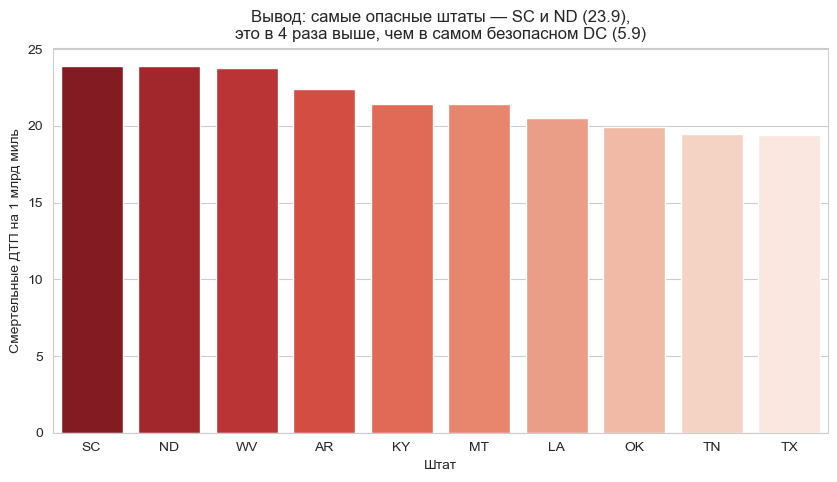

In [6]:
top10 = df.sort_values('total', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='abbrev', y='total', hue='abbrev', palette='Reds_r', legend=False)
plt.title('Вывод: самые опасные штаты — SC и ND (23.9),\n'
          'это в 4 раза выше, чем в самом безопасном DC (5.9)', fontsize=12)
plt.xlabel('Штат')
plt.ylabel('Смертельные ДТП на 1 млрд миль')
plt.show()

## 2. Что сильнее всего связано с аварийностью? (корреляция)

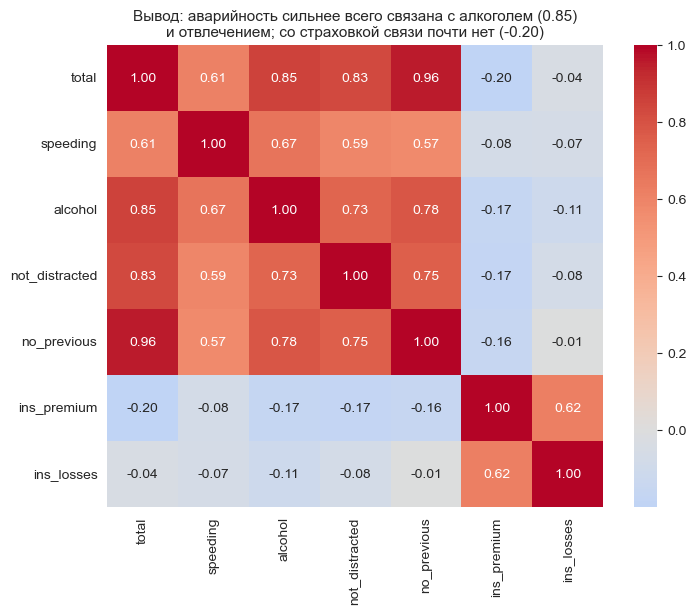

In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Вывод: аварийность сильнее всего связана с алкоголем (0.85)\n'
          'и отвлечением; со страховкой связи почти нет (-0.20)', fontsize=11)
plt.show()

## 3. Алкоголь vs аварийность (scatter + линия тренда)

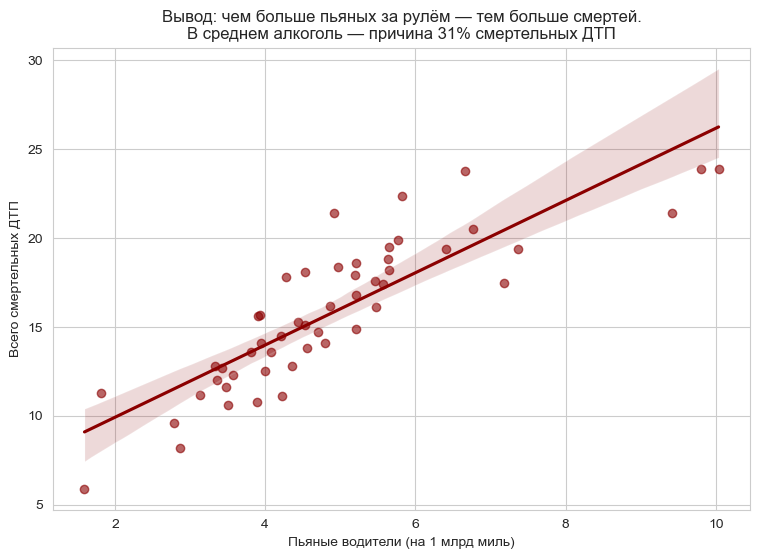

In [8]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x='alcohol', y='total', color='darkred',
            scatter_kws={'alpha': 0.6})
plt.title('Вывод: чем больше пьяных за рулём — тем больше смертей.\n'
          'В среднем алкоголь — причина 31% смертельных ДТП', fontsize=12)
plt.xlabel('Пьяные водители (на 1 млрд миль)')
plt.ylabel('Всего смертельных ДТП')
plt.show()

## 4. Парадокс страховки: больше аварий ≠ дороже страховка

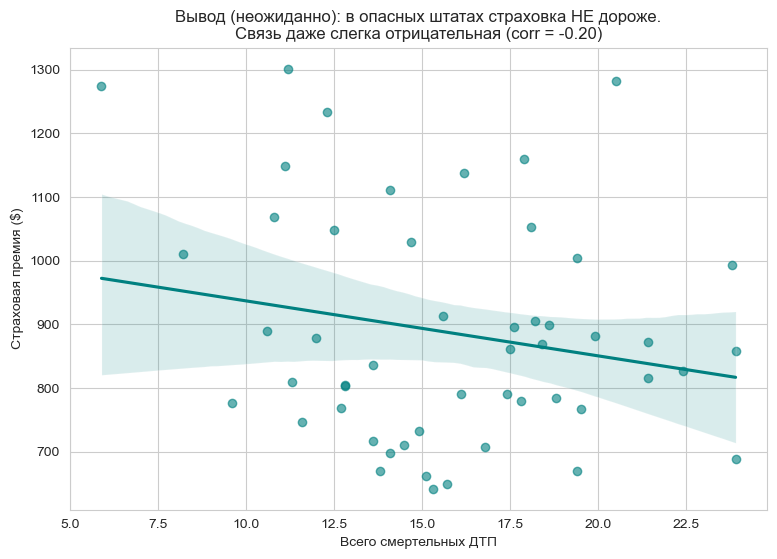

In [9]:
plt.figure(figsize=(9, 6))
sns.regplot(data=df, x='total', y='ins_premium', color='teal',
            scatter_kws={'alpha': 0.6})
plt.title('Вывод (неожиданно): в опасных штатах страховка НЕ дороже.\n'
          'Связь даже слегка отрицательная (corr = -0.20)', fontsize=12)
plt.xlabel('Всего смертельных ДТП')
plt.ylabel('Страховая премия ($)')
plt.show()

## 📌 Итоговые выводы

1. **Самые опасные штаты** — Южная Каролина (SC) и Северная Дакота (ND): 23.9 смертельных ДТП на 1 млрд миль. Самый безопасный — округ Колумбия (DC): всего 5.9, разница в **4 раза**.
2. **Алкоголь — главный фактор**: сильнейшая корреляция с общей аварийностью (0.85), в среднем виновен в **31%** смертельных ДТП.
3. **Отвлечение и превышение скорости** тоже сильно связаны с авариями.
4. **Парадокс страховки**: в более опасных штатах страховка НЕ дороже (corr = −0.20) — цена премии определяется другими факторами (плотность населения, стоимость ремонта, законы штата), а не аварийностью.